# Dive Deeper — SQL Query

Notebook ini adalah latihan **Dive Deeper** untuk materi **SQL Query** menggunakan `sqlite3` dengan database **`telco.db`** (skema pada ERD di bawah).

---


## Dataset & Skema

- File: `telco.db` (SQLite)
- ERD ringkas:


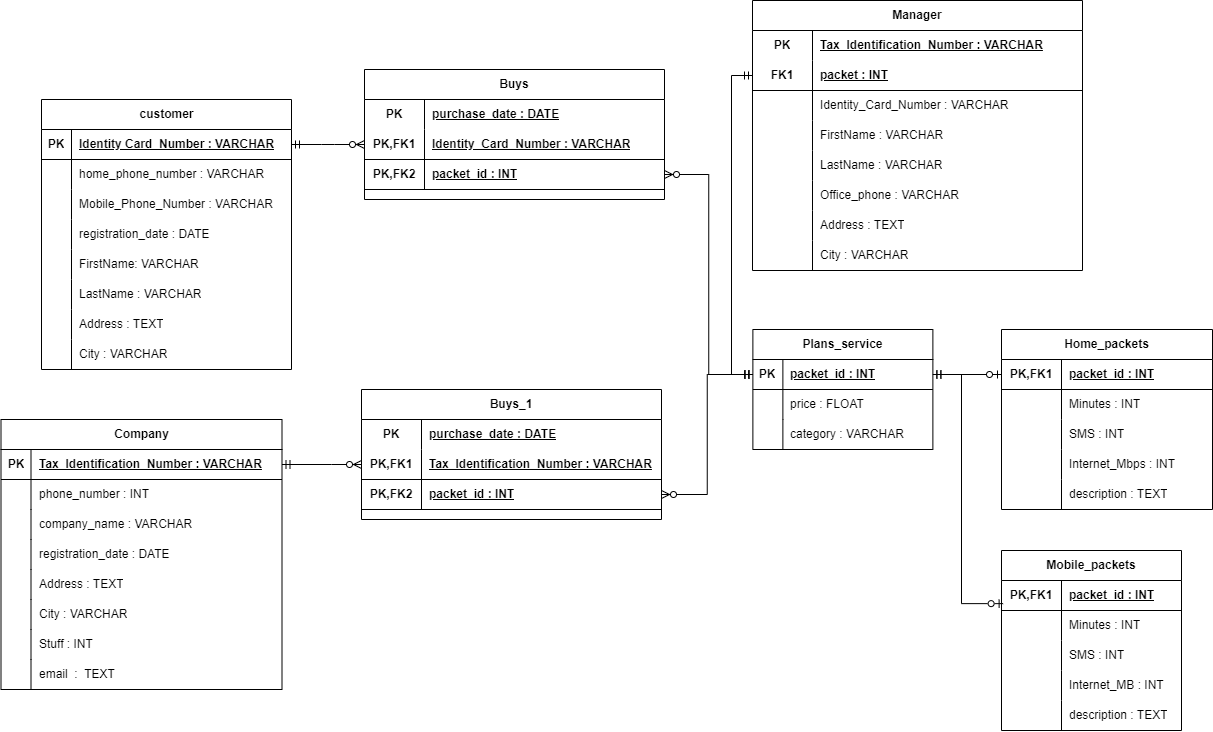

> Hint tabel kunci:
- `customer(Identity_Card_Number, ...)`
- `Company(Tax_Identification_Number, ...)`
- `Buys(Identity_Card_Number, packet_id, purchase_date)` — transaksi pelanggan individu
- `Buys_1(Tax_Identification_Number, packet_id, purchase_date)` — transaksi corporate
- `Plans_service(packet_id, price, category)` — metadata paket (harga & kategori)
- `Home_packets(packet_id, ...)`, `Mobile_packets(packet_id, ...)` — detail paket by jenis

---


## Setup Database Connection

Sebelum kita dapat mengakses database `sqlite3`, kita perlu mengimport library tersebut dan mendefinisikan connection ke Python:

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('data_input/telco.db')

## TASK 1

**Goal:** Cari pelanggan **individu** dengan **total pengeluaran** (sum harga paket yang dibeli) **di atas rata‑rata total pengeluaran seluruh pelanggan**.

In [20]:
# code here

query = """
with cte as (
SELECT customer.Identity_Card_Number,
sum(plans_services.price) as total_price
from customer
left join Buys on customer.Identity_Card_Number = Buys.Identity_Card_Number
left join plans_services on Buys.packet_id = plans_services.packet_id
group by customer.Identity_Card_Number
)
SELECT cte.Identity_Card_Number,
cte.total_price
from cte
where total_price > (select avg(total_price) from cte)
"""

df = pd.read_sql_query(query, conn)
df

,Identity_Card_Number,total_price
0,AK000145,39.9
1,AK000154,37.5
2,AK000187,39.9
3,AK000215,29.9
4,AK000254,29.9
5,AK000289,29.9
6,AK000452,29.9
7,AK000457,39.9
8,AK000478,29.9
9,AK000521,37.5


## TASK 2

**Goal:** Hitung **penjualan bulanan** lalu ambil **Top‑3 bulan** per **category** plan service berdasarkan revenue.

In [51]:
# code here
query = """
with cte as (
select
STRFTIME('%m', Buys.purchase_date) as purchase_month,
plans_services.category,
sum(plans_services.price) as total_revenue,
rank() over (partition by category order by sum(plans_services.price) desc) as rank
from Buys
left join plans_services on Buys.packet_id = plans_services.packet_id
group by purchase_month, plans_services.category
)
select * from cte
where rank <= 3
"""
df = pd.read_sql_query(query, conn)
df

,purchase_month,category,total_revenue,rank
0,11,FAMILY,134.7,1
1,10,FAMILY,114.9,2
2,09,FAMILY,109.7,3
3,02,PROFESSIONAL,37.5,1
4,05,PROFESSIONAL,37.5,1
5,10,PROFESSIONAL,37.5,1
6,12,PROFESSIONAL,37.5,1
7,03,STUDENT,102.2,1
8,02,STUDENT,94.8,2
9,08,STUDENT,82.3,3


## TASK 3

**Goal A:** Buat ranking per `category` berdasarkan penjualan

**Goal B:** Hitung **running total** penjualan bulanan per `category`

**A. Top‑3 Bulan per Kategori**

**B. Running Total Revenue Bulanan**

In [54]:
# code here
# code here
query = """
with cte as (
select
STRFTIME('%m', Buys.purchase_date) as purchase_month,
plans_services.category,
sum(plans_services.price) as total_revenue,
rank() over (partition by category order by sum(plans_services.price) desc) as rank,
sum(sum(plans_services.price)) over (partition by category order by STRFTIME('%m', Buys.purchase_date)) as monthly_revenue
from Buys
left join plans_services on Buys.packet_id = plans_services.packet_id
group by purchase_month, plans_services.category
)
select * from cte
order by purchase_month, category
"""
df = pd.read_sql_query(query, conn)
df


,purchase_month,category,total_revenue,rank,monthly_revenue
0,01,FAMILY,64.9,5,64.9
1,01,STUDENT,22.5,7,22.5
2,02,FAMILY,94.8,4,159.7
3,02,PROFESSIONAL,37.5,1,37.5
4,02,STUDENT,94.8,2,117.3
5,03,FAMILY,29.9,7,189.6
6,03,STUDENT,102.2,1,219.5
7,04,FAMILY,39.9,6,229.5
8,04,STUDENT,19.9,9,239.4
9,05,FAMILY,25.0,9,254.5
